In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('diabetes_binary_health_indicators.csv')


In [14]:
print("Dataset Shape:", df.shape)

Dataset Shape: (253680, 22)


In [15]:
print("\nMissing Values:")


Missing Values:


In [16]:
print(df.isnull().sum())

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64


In [17]:
display(df.head())

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


/tmp/ipykernel_6017/1473831084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Diabetes_binary', data=df, palette='Set2')


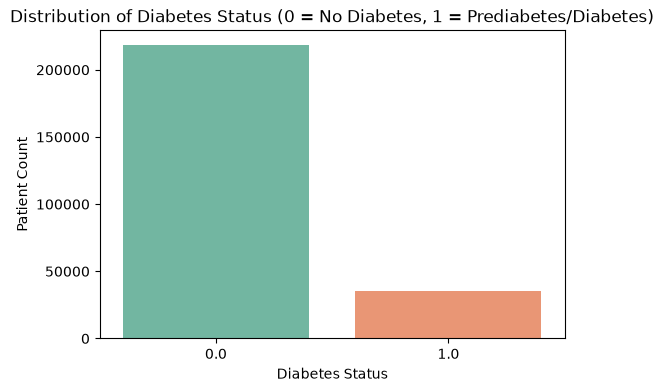

Percentage Breakdown:
Diabetes_binary
0.0    86.066698
1.0    13.933302
Name: proportion, dtype: float64


In [18]:
# Target distribution overview
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Diabetes_binary', data=df, palette='Set2')
plt.title('Distribution of Diabetes Status (0 = No Diabetes, 1 = Prediabetes/Diabetes)')
plt.xlabel('Diabetes Status')
plt.ylabel('Patient Count')
plt.show()

print("Percentage Breakdown:")
print(df['Diabetes_binary'].value_counts(normalize=True) * 100)

/tmp/ipykernel_6017/1235883308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Diabetes_binary', y='BMI', data=df, palette='Pastel1')


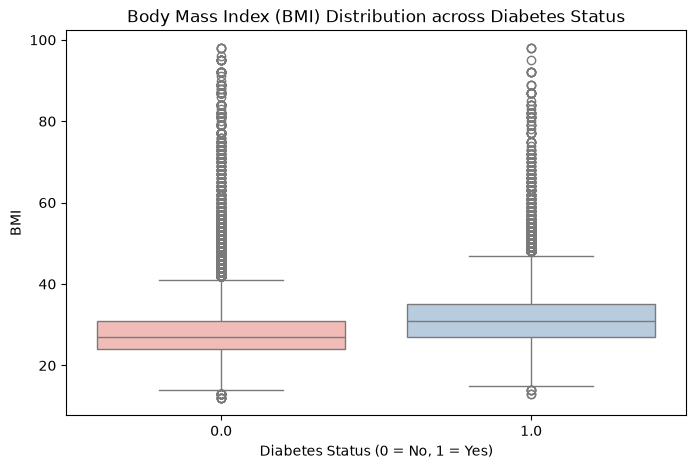

BMI Statistics by Group:


,mean,median,min,max,std
Diabetes_binary,,,,,
0.0,27.805770,27.0,12.0,98.0,6.291414
1.0,31.944011,31.0,13.0,98.0,7.363401


In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Diabetes_binary', y='BMI', data=df, palette='Pastel1')
plt.title('Body Mass Index (BMI) Distribution across Diabetes Status')
plt.xlabel('Diabetes Status (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.show()

# Aggregate group statistics
bmi_stats = df.groupby('Diabetes_binary')['BMI'].agg(['mean', 'median', 'min', 'max', 'std'])
print("BMI Statistics by Group:")
display(bmi_stats)

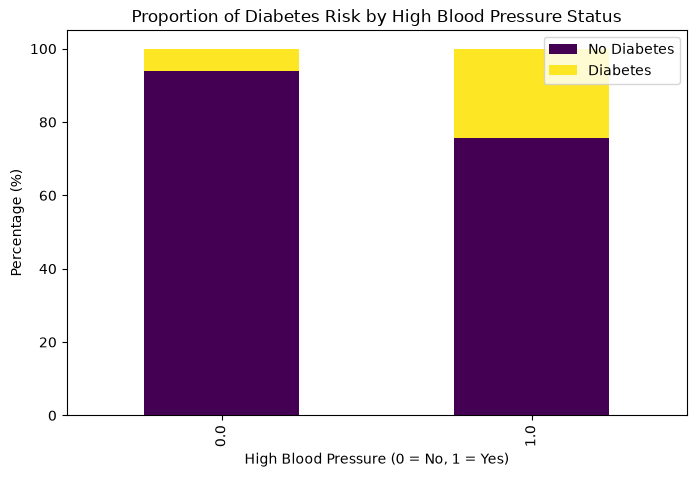

In [20]:
# Crosstab analysis of High Blood Pressure vs Diabetes
bp_diabetes = pd.crosstab(df['HighBP'], df['Diabetes_binary'], normalize='index') * 100
bp_diabetes.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
plt.title('Proportion of Diabetes Risk by High Blood Pressure Status')
plt.xlabel('High Blood Pressure (0 = No, 1 = Yes)')
plt.ylabel('Percentage (%)')
plt.legend(['No Diabetes', 'Diabetes'], loc='upper right')
plt.show()

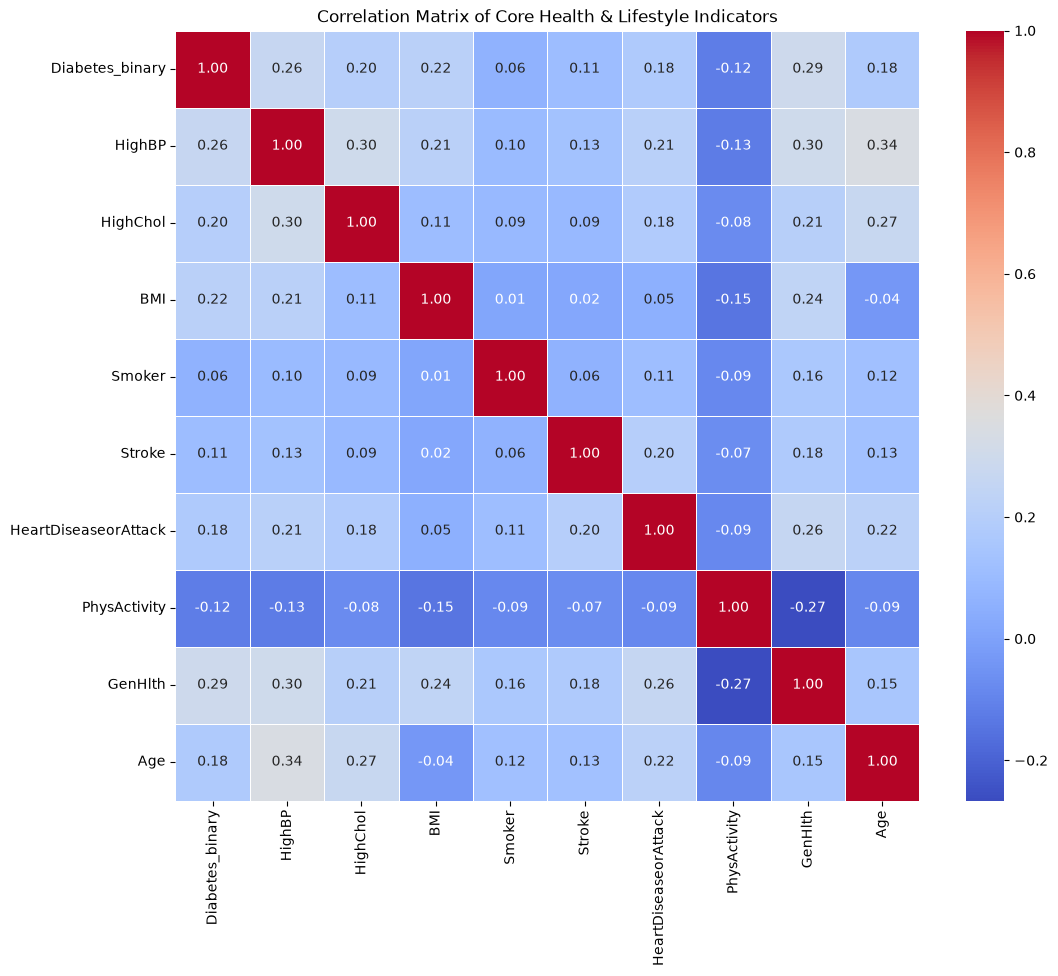

In [21]:
plt.figure(figsize=(12, 10))
corr = df[['Diabetes_binary', 'HighBP', 'HighChol', 'BMI', 'Smoker', 'Stroke', 
           'HeartDiseaseorAttack', 'PhysActivity', 'GenHlth', 'Age']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Core Health & Lifestyle Indicators')
plt.show()

# Save processed aggregate insights for the web app UI
corr.to_csv('diabetes_correlation_summary.csv')

Evaluation

Body Weight Matters (BMI): People who have diabetes tend to have a higher body mass index (BMI) on average, showing a strong link between weight and metabolic health.

Blood Pressure Connection: High blood pressure (hypertension) heavily overlaps with diabetes risk, meaning cardiovascular strain and blood sugar issues often go hand-in-hand.

Lifestyle Protection: Regular physical activity and healthy daily habits act as a natural buffer, lowering the overall concentration of high-risk cases.

Age Factor: Risk levels grow steadily as people get older, highlighting the importance of regular check-ups with age.

(BMI Distribution): Compares body weight spread between non-diabetic and diabetic groups, demonstrating how weight levels shift upward for those diagnosed.

(Blood Pressure Impact): Breaks down the proportion of diabetes cases across normal vs. high blood pressure patients, showing the amplified risk in the high blood pressure group.